# Análise da Jornada do Usuário e Experimento A/A/B

Fabrício Camacho

Data: 15/02/2026

## 1 - Introdução e Objetivos

Este projeto investiga o comportamento dos usuários de um aplicativo de produtos alimentícios. O foco central é entender o fluxo de navegação através de um funil de vendas e validar o impacto de alterações na interface (UI) através de métodos estatísticos.

**Os principais objetivos são**:

- Mapear o Funil de Vendas: Identificar as etapas de MainScreenAppear, OffersScreenAppear, CartScreenAppear e PaymentScreenSuccessful, quantificando as taxas de conversão e os pontos de maior abandono (churn).

- Avaliar a Estabilidade do Experimento (Teste A/A): Verificar se os grupos de controle (241 e 242) são estatisticamente idênticos para garantir a precisão do teste.

- Validar Hipóteses (Teste A/B): Determinar se a introdução de uma nova fonte no aplicativo alterou a conversão de vendas (Grupo 243) em comparação aos grupos originais.

- Análise de Significância: Utilizar o Teste Z de proporções para embasar a tomada de decisão com um nível de confiança de 95%.

## 2 - Carregamento e Pré-processamento de Dados

In [158]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import plotly.graph_objects as go

# Carregando dataset
df_log = pd.read_csv('datasets/logs_exp_us.csv', sep='\t')

# Visualizando dados
df_log.info()
df_log.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248
5,CartScreenAppear,6217807653094995999,1564055323,248
6,OffersScreenAppear,8351860793733343758,1564066242,246
7,MainScreenAppear,5682100281902512875,1564085677,246
8,MainScreenAppear,1850981295691852772,1564086702,247
9,MainScreenAppear,5407636962369102641,1564112112,246


Observações: É possível observar que: 
- O nome das colunas está com maiúsculas e minúsculas;
- A coluna EventTimestamp não está no formato datetime, mas sim em timestamp;
- As colunas "DeviceIDHash" e "ExpId" estão em formato int64 e devem estar nos formatos "str" e "category", respectivamente;
- Aparentemente, o dataframe não apresenta dados nulos. 

### 2.1 Tratamento dos dados

De acordo com essas observações, deveremos seguir com as seguintes etapas para o pré-processamento dos dados:

1. Converter os nomes das colunas para snake_case;
2. Converter a coluna ExpId para category;
3. Converter a coluna DeviceIDHash para str;
4. Converter a coluna EventTimestamp para datetime;
5. Criar novas colunas com valores somente com datas dos eventos.
6. Checar usuários repetidos entre os grupos dos experimentos e remove-los caso existam

Além disso, devemos verificar a consistência dos dados em busca de dados discrepantes que possam interferir nos resultados. Isso será realizado através da observação da distribuição dos dados nas datas presentes no dataset.

In [159]:
# Converter as colunas para padrão snake_case
df_log.columns = ['event_name', 'device_id_hash', 'event_timestamp', 'exp_id']

# Convertendo a coluna ExpId para categoria
df_log['exp_id'] = df_log['exp_id'].astype('category')

# Convertendo a coluna DeviceIdHash para str
df_log['device_id_hash'] = df_log['device_id_hash'].astype('str')

# Convertendo a coluna EventTimestamp para datetime
df_log['event_timestamp'] = pd.to_datetime(df_log['event_timestamp'], unit='s')

# Criando nova coluna com a data do evento
df_log['event_date'] = df_log['event_timestamp'].dt.date

# Imprimindo informações do DataFrame
df_log.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       244126 non-null  object        
 1   device_id_hash   244126 non-null  object        
 2   event_timestamp  244126 non-null  datetime64[ns]
 3   exp_id           244126 non-null  category      
 4   event_date       244126 non-null  object        
dtypes: category(1), datetime64[ns](1), object(3)
memory usage: 7.7+ MB


### 2.2 - Checagem de usuários repetidos entre experimentos

In [160]:
# Criando conjunto de ids únicos por grupo
group_246_a = set(df_log[df_log['exp_id'] == 246]['device_id_hash'])
group_247_a = set(df_log[df_log['exp_id'] == 247]['device_id_hash'])
group_248_b = set(df_log[df_log['exp_id'] == 248]['device_id_hash'])

# Verificando intersecções
inter_246_247 = group_246_a.intersection(group_247_a)
inter_246_248 = group_246_a.intersection(group_248_b)
inter_247_248 = group_247_a.intersection(group_248_b)

# Checando resultados
print(f'Usuários nos grupos 246 e 247 simultaneamente: {len(inter_246_247)}')
print(f'Usuários nos grupos 246 e 248 simultaneamente: {len(inter_246_248)}')
print(f'Usuários nos grupos 247 e 248 simultaneamente: {len(inter_247_248)}')


Usuários nos grupos 246 e 247 simultaneamente: 0
Usuários nos grupos 246 e 248 simultaneamente: 0
Usuários nos grupos 247 e 248 simultaneamente: 0


Observações: Não há necessidade de remoção de usuários, pois não existe usuários repetidos entre os experimentos.
### 2.3 - Checagem de Estatísticas Gerais e Distribuição dos Dados
Aqui faremos uma análise exploratória e limpeza temporal, fundamental para garantir que o teste estatístico não seja afetado por dados "sujos" ou incompletos. Vamos:
- Checar métricas gerais dos dados;
- Analisar histograma de distribuição dos dados para verificar como os dados estão distribuidos nos dias;
- Checar se há necessidade de remoção de dados "sujos".
#### 2.3.1 - Métricas Gerais dos dados

In [161]:
# Quantidade de eventos (linhas no DF)
total_events = len(df_log)

# Quantidade de usuários únicos
total_users = df_log['device_id_hash'].nunique()

# Média de eventos por usuário
avg_events_per_user = total_events / total_users

print(f"Total de eventos: {total_events}")
print(f"Total de usuários: {total_users}")
print(f"Média de eventos por usuário: {avg_events_per_user:.2f}")

Total de eventos: 244126
Total de usuários: 7551
Média de eventos por usuário: 32.33


#### 2.3.2 - Período de Tempo dos Dados e Histograma

Data mínima: 2019-07-25
Data máxima: 2019-08-07


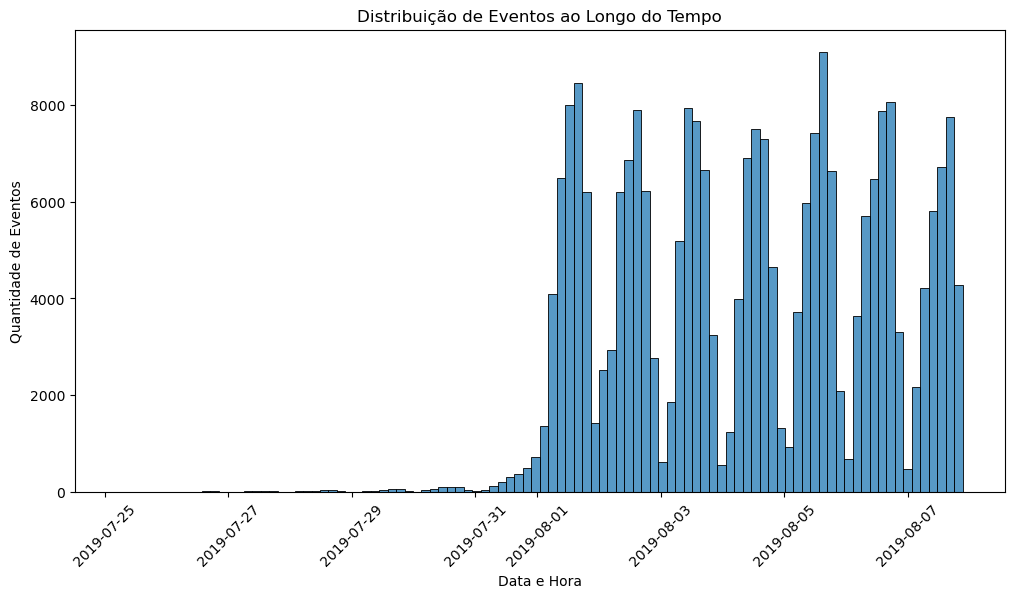

In [162]:
# Datas mínima e máxima
min_date = df_log['event_date'].min()
max_date = df_log['event_date'].max()

print(f"Data mínima: {min_date}")
print(f"Data máxima: {max_date}")

# Histograma por data e hora
plt.figure(figsize=(12, 6))
sns.histplot(df_log['event_timestamp'], bins=100, kde=False)
plt.title('Distribuição de Eventos ao Longo do Tempo')
plt.xlabel('Data e Hora')
plt.ylabel('Quantidade de Eventos')
plt.xticks(rotation=45)
plt.show()


Observações: É possível notar pela distribuição dos dados que os eventos são mais estáveis a partir de 01/08/2019. Assim precisamos avaliar se a retirada dos dados anteriores a essa data correspondem a uma grande parcela dos dados ou se é possúvel retira-los.
#### 2.3.3 - Verificando Possibilidade de Retirar Dados Anteriores a 01/08/2019


In [163]:
# Entendendo proporção de dados desatualizados
df_log_filtered = df_log[df_log['event_timestamp'] >= '2019-08-01']
n_log_outdated = (1 - (len(df_log_filtered) / len(df_log))) * 100

# Checando informações dos dados filtrados
total_events_filtered = len(df_log_filtered)
total_users_filtered = df_log_filtered['device_id_hash'].nunique()
avg_events_per_user_filtered = total_events_filtered / total_users_filtered

# Mostrando resultados
print(f'Porcentagem de dados desatualizados: {n_log_outdated:.2f}%')
print(f"Total de eventos após filtragem: {total_events_filtered}")
print(f"Total de usuários após filtragem: {total_users_filtered}")
print(f"Média de eventos por usuário após filtragem: {avg_events_per_user_filtered:.2f}")
print("Quantidade de dados nas amostras dos experimentos após filtragem:")
print(df_log_filtered['exp_id'].value_counts())

Porcentagem de dados desatualizados: 1.16%
Total de eventos após filtragem: 241298
Total de usuários após filtragem: 7534
Média de eventos por usuário após filtragem: 32.03
Quantidade de dados nas amostras dos experimentos após filtragem:
exp_id
248    84726
246    79425
247    77147
Name: count, dtype: int64


Observações: Devido ao fato de apenas 1,16% dos dados serem anteriores a 01/08/2019, sua remoção não compromete a representatividade estatística. Mesmo após o ajuste, o tamanho amostral ($N$) permanece substancial para a realização de testes robustos. A exclusão desses dados residuais mitiga ruídos e garante uma análise mais decisiva, focando exclusivamente no período em que os dados apresentam maior estabilidade.

## 3 - Estudo de Funil de Vendas
Aqui calculamos a jornada do usuário do primeiro contato até o pagamento bem-sucedido. Esta etapa é crucial para encontrar onde os usuários estão saindo do funil determinado.

Primeiramente, vamos verificar a distribuição dos dados de acordo com o nome (event_name) do evento.

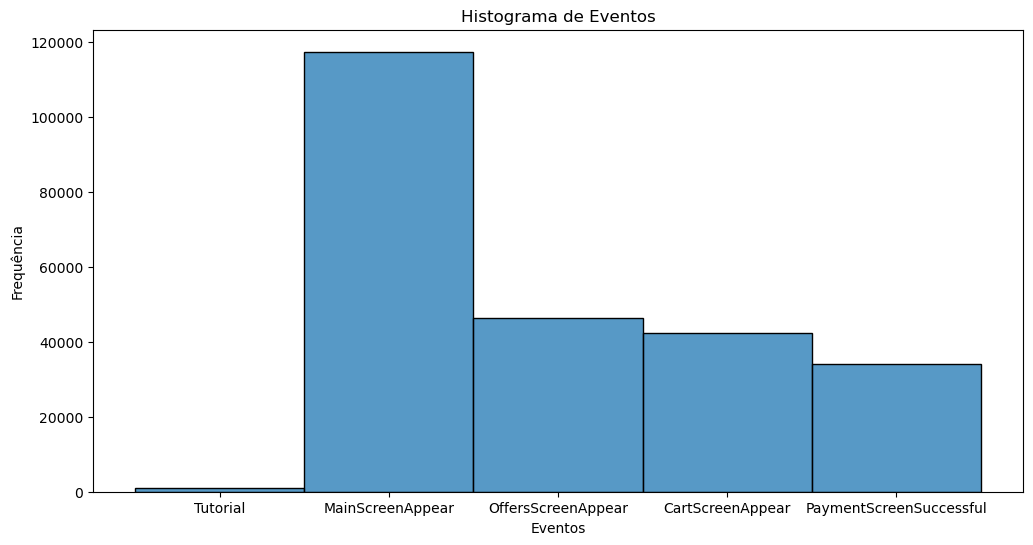

In [164]:
# Criando histograma dos eventos
plt.figure(figsize=(12, 6))
sns.histplot(data=df_log_filtered['event_name'])
plt.title('Histograma de Eventos')
plt.xlabel('Eventos')
plt.ylabel('Frequência')

# Exibindo gráfico
plt.show()


Observações: diante dos resultados encontrados, é possível presumir o seguinte fluxo de vendas:

1 - **MainScreenAppear**: O ponto de entrada. O usuário abriu o app e viu a vitrine principal.

2 - **OffersScreenAppear**: O usuário clicou em uma categoria ou viu ofertas específicas. Em apps de produtos alimentícios, isso seria o passo entre "abrir o app" e "escolher um item".

3 - **CartScreenAppear**: O usuário demonstrou intenção real de compra ao colocar algo no carrinho e visualizar a lista.

4 - **PaymentScreenSuccessful**: O pagamento foi processado e a venda convertida.

A etapa **Tutorial** é um evento lateral, uma vez que nem todo mundo vê o tutorial antes de comprar. Se forçarmos o tutorial como a primeira etapa do funil, os números de conversão podem parecer muito menores do que são na realidade, pois excluiria todos os usuários que já sabem usar o app. Por esse motivo, não vamos considerar a etapa **Tutorial** no fluxo de vendas. Dessa forma, vamos realizar as seguintes etapas para analisar o funil de vendas:

1 - Preparar os dados: Retirando as etapas de "Tutorial" existentes nos dados e organizar os eventos em ordem lógica do fluxo definido acima;

2 - Calcular taxa de conversão: Entender a conversão total (% em relação a primeira etapa) e a conversão por etapa (% em relação a etapa anterior);

3 - Visualização gráfica: Visualizar o funil de vendas de forma gráfica. 
### 3.1 - Preparar os dados para o funil
Aqui vamos retirar a etapa de "Tutorial" existente nos dados e organizar os eventos em ordem lógica do fluxo, contando o nũmero de usuários unívocos em cada etapa.

In [165]:
# Definir etapas do funil de vendas sem considerar a etapa 'Tutorial'
funnel_steps = [
    'MainScreenAppear', 
    'OffersScreenAppear', 
    'CartScreenAppear', 
    'PaymentScreenSuccessful'
    ]

# Agrupando as etapas e contando o número de usuários únicos em cada uma delas
funnel_df = (
    df_log_filtered[df_log_filtered['event_name'].isin(funnel_steps)]
    .groupby('event_name')['device_id_hash']
    .nunique()
    .reindex(funnel_steps) # Reindexando para que a ordem seja a mesma
    .reset_index()
    )
funnel_df.columns = ['event_name', 'users']

# Mostrando os resultados
print(funnel_df)


                event_name  users
0         MainScreenAppear   7419
1       OffersScreenAppear   4593
2         CartScreenAppear   3734
3  PaymentScreenSuccessful   3539


### 3.2 - Calculando taxas de conversão
Aqui vamos entender a conversão total (% em relação a primeira etapa) e a conversão por etapa (% em relação a etapa anterior);

In [166]:
# Verificando a conversão total: Porcentagem em relação a primeira etapa
funnel_df['total_conversion'] = (100* funnel_df['users'] / funnel_df['users'].iloc[0]).round(2)

# Verificando a conversão por etapa: Porcentagem em relação a etapa anterior
funnel_df['step_conversion'] = (
    funnel_df['users']
    .pct_change() # Calcula a variação percentual entre a linha atual e a linha anterior, informando um valor negativo, neste caso.
    .add(1) # Adiciona 1 para converter a variação percentual em coeficiente de retenção (ex: -0.2 vira 0.8, ou seja, 80% de retenção)
    .mul(100) # Transforma o coeficiente em porcentagem
    .fillna(100) # Preenche o valor da primeira etapa em 100%, já que o pandas entregará NaN.
    .round(2) # Arredonda os valores para 2 casas decimais
    )

# Mostrando os resultados
print(funnel_df)


                event_name  users  total_conversion  step_conversion
0         MainScreenAppear   7419            100.00           100.00
1       OffersScreenAppear   4593             61.91            61.91
2         CartScreenAppear   3734             50.33            81.30
3  PaymentScreenSuccessful   3539             47.70            94.78


### 3.3 - Visualização gráfica
Aqui vamos visualizar o funil de vendas de forma gráfica.

In [167]:
# Criando gráfico de Funil de Vendas
fig = go.Figure(go.Funnel(
    y = funnel_df['event_name'],
    x = funnel_df['users'],
    textinfo = "value+percent initial+percent previous",
    # Customizando o que aparece ao passar o mouse:
    hovertemplate = (
        "<b>Etapa:</b> %{y}<br>" +
        "<b>Usuários:</b> %{x}<br>" +
        "<b>Conversão do Topo:</b> %{percentInitial}<br>" +
        "<b>Retenção da Etapa:</b> %{percentPrevious}" +
        "<extra></extra>" # Remove o nome da série/rótulo lateral, qu enão faz sentido.
    )
))

fig.update_layout(title_text='Funil de Vendas - Conversão de Usuários Únicos')
fig.show()


Observações: É possível observar que a maior perda de clientes se dá entre MainScreenAppear e OffersScreenAppear, perdendo cerca de 38% dos clientes que acessaram a tela pricipal. Isso significa que, ao acessar a tela de ofertas, na segunda etapa, muitos clientes desistem de comprar. A taxa de retenção nas demais etapas é superior a 80%, evidenciando que a mudança da primeira para a segunda etapa é, de fato, o momento em que há maior perda de clientes.
## 4 - Significância Estatística
Para o teste A/A/B, usamos o Teste Z para proporções. Implementamos a Correção de Bonferroni para lidar com múltiplos testes e reduzir a chance de falsos positivos, que podem ser grandes, pois estamos testando 4 etapas diferentes do funil de vendas. Aqui vamos:
- Definir alfa como 0,05;
- Comparar os grupos A1 vs A2: se o valor-p for maior que alfa em todas as etapas, então o experimento é válido;
- Comparar os grupos A1 vs B e A2 vc B: verificamos a consistência do efeito;
- Comparar (A1 + A2) vc B: aumentamos o poder estatístico para a decisão final.

In [168]:
# Definindo alpha e criando função para realização de teste Z
alpha = 0.05

def run_funnel_ztest(df, group1_ids, group2_ids, funnel_steps, alpha):
    """ Realiza o teste Z de proporções para cada etapa do funil entre dois conjuntos de grupos.
    Args:
        df: dataframe com os dados
        group1_ids: lista com ids do grupo 1
        group2_ids: lista com ids do grupo 2
        funnel_steps: lista com os nomes das etapas do funil
        alpha: nível de significância do teste
    """
    results = []
    
    # Calculando total de usuários únicos em cada grupo
    n_g1 = df[df['exp_id'].isin(group1_ids)]['device_id_hash'].nunique()
    n_g2 = df[df['exp_id'].isin(group2_ids)]['device_id_hash'].nunique()
    
    for step in funnel_steps:
        # Sucessos (usuários únicos que atingiram a etapa)
        s_g1 = df[df['exp_id'].isin(group1_ids) & (df['event_name'] == step)]['device_id_hash'].nunique()
        s_g2 = df[df['exp_id'].isin(group2_ids) & (df['event_name'] == step)]['device_id_hash'].nunique()
        
        # Test Z
        stat, pval = proportions_ztest([s_g1, s_g2], [n_g1, n_g2])
        
        # Salvando resultados
        results.append({
            'Etapa': step,
            'g1_conv': f'{(s_g1/n_g1):.2%}',
            'g2_conv': f'{(s_g2/n_g2):.2%}',
            'p_value': round(pval, 4),
            'Significante': 'Sim' if pval < alpha else 'Não'
        })
    return pd.DataFrame(results)


In [169]:
# Aplicando teste A/A - O objetivo é que não seja significante
print("--- TESTE A/A (VALIDAÇÃO DO SISTEMA) ---")
aa_results = run_funnel_ztest(df_log_filtered, [246], [247], funnel_steps, alpha)
display(aa_results)

# Verificando a consistência dos dados
# Aplicando teste A1/B
print("--- TESTE A1/B ---")
a1b_results = run_funnel_ztest(df_log_filtered, [246], [248], funnel_steps, alpha)
display(a1b_results)

# Aplicando teste A2/B
print("--- TESTE A2/B ---")
a2b_results = run_funnel_ztest(df_log_filtered, [247], [248], funnel_steps, alpha)
display(a2b_results)

# Aumentando o poder estatístico para decisão final
# Aplicando teste A/B Combinado (241+242 vs 243)
print("--- TESTE A/B (CONTROLE COMBINADO VS TESTE) ---")
ab_results = run_funnel_ztest(df_log_filtered, [246, 247], [248], funnel_steps, alpha)
display(ab_results)


--- TESTE A/A (VALIDAÇÃO DO SISTEMA) ---


,Etapa,g1_conv,g2_conv,p_value,Significante
0,MainScreenAppear,98.63%,98.53%,0.7571,Não
1,OffersScreenAppear,62.08%,60.49%,0.2481,Não
2,CartScreenAppear,50.97%,49.26%,0.2288,Não
3,PaymentScreenSuccessful,48.31%,46.08%,0.1146,Não


--- TESTE A1/B ---


,Etapa,g1_conv,g2_conv,p_value,Significante
0,MainScreenAppear,98.63%,98.27%,0.2950,Não
1,OffersScreenAppear,62.08%,60.35%,0.2084,Não
2,CartScreenAppear,50.97%,48.48%,0.0784,Não
3,PaymentScreenSuccessful,48.31%,46.55%,0.2123,Não


--- TESTE A2/B ---


,Etapa,g1_conv,g2_conv,p_value,Significante
0,MainScreenAppear,98.53%,98.27%,0.4587,Não
1,OffersScreenAppear,60.49%,60.35%,0.9198,Não
2,CartScreenAppear,49.26%,48.48%,0.5786,Não
3,PaymentScreenSuccessful,46.08%,46.55%,0.7373,Não


--- TESTE A/B (CONTROLE COMBINADO VS TESTE) ---


,Etapa,g1_conv,g2_conv,p_value,Significante
0,MainScreenAppear,98.58%,98.27%,0.2942,Não
1,OffersScreenAppear,61.28%,60.35%,0.4343,Não
2,CartScreenAppear,50.11%,48.48%,0.1818,Não
3,PaymentScreenSuccessful,47.19%,46.55%,0.6004,Não


Observações: Diante dos resultados dos testes estatísticos, é possível afirmar que:
- Não há diferença significativa entre as etapas dos grupos controle (A/A), evidenciando que os mesmos foram separados corretamente;
- Não há diferença significativa entre os grupos controle e o grupo teste em nenhuma das etapas, mesmo quando os testes foram feitos com os dois grupos controle sendo comparados com o grupo teste separadamente ou em conjunto;
- A Correção de Benferroni se mostrou desnecessária, uma vez que não houve resultados significativos.
## 5 - Conclusões e Recomendações
Após análise do comportamento dos usuários e da realização de testes A/A/B, chegamos às seguintes conclusões:

- **Integridade dos Dados**: O teste A/A entre os grupos 246 e 247 não apresentou diferenças estatisticamente significantes em nenhuma etapa do funil. Isso valida a ferramenta de segmentação e garante que os usuários foram divididos de forma aleatória e equilibrada, tornando os resultados do experimento confiáveis.

- **Impacto da Nova Fonte**: O teste A/B (comparando o grupo 248 com os grupos de controle) demonstrou que a alteração da fonte no aplicativo não causou impacto estatisticamente significante nas taxas de conversão. O comportamento de compra permaneceu estável em todas as etapas, do acesso à tela principal até a finalização do pagamento.

- **Análise do Funil**: Observou-se que a maior "perda" de usuários ocorre entre a tela inicial (MainScreenAppear) e a tela de ofertas (OffersScreenAppear). Esta é uma oportunidade de melhoria de produto que independe da fonte utilizada.

**Recomendação Final**:
Dado que a alteração de design (fonte) não gerou ganho de conversão, mas também não prejudicou a experiência atual, a decisão de implementação pode ser baseada em critérios de branding ou performance técnica. No entanto, para aumentar as vendas, recomenda-se focar em experimentos que otimizem a transição da tela principal para as ofertas, onde reside o maior gargalo do funil.